In [234]:
import pandas as pd
import matplotlib.pyplot as plt

# Load NAV data
nav = pd.read_csv("../data/processed/02_nav_history.csv")

# Check data
print(nav.head())
print("\nShape:", nav.shape)

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692

Shape: (46000, 3)


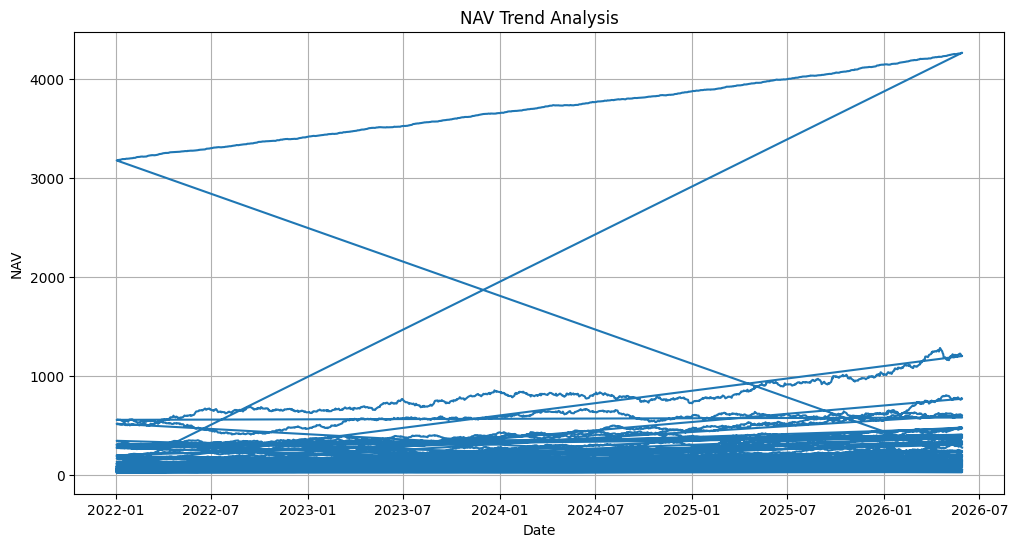

In [235]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Plot NAV Trend
plt.figure(figsize=(12, 6))
plt.plot(nav["date"], nav["nav"])

plt.title("NAV Trend Analysis")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True)

plt.show()

In [236]:
import seaborn as sns

# Load AUM data
aum = pd.read_csv("../data/processed/03_aum_by_fund_house.csv")

print(aum.head())
print("\nShape:", aum.shape)

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168

Shape: (90, 5)


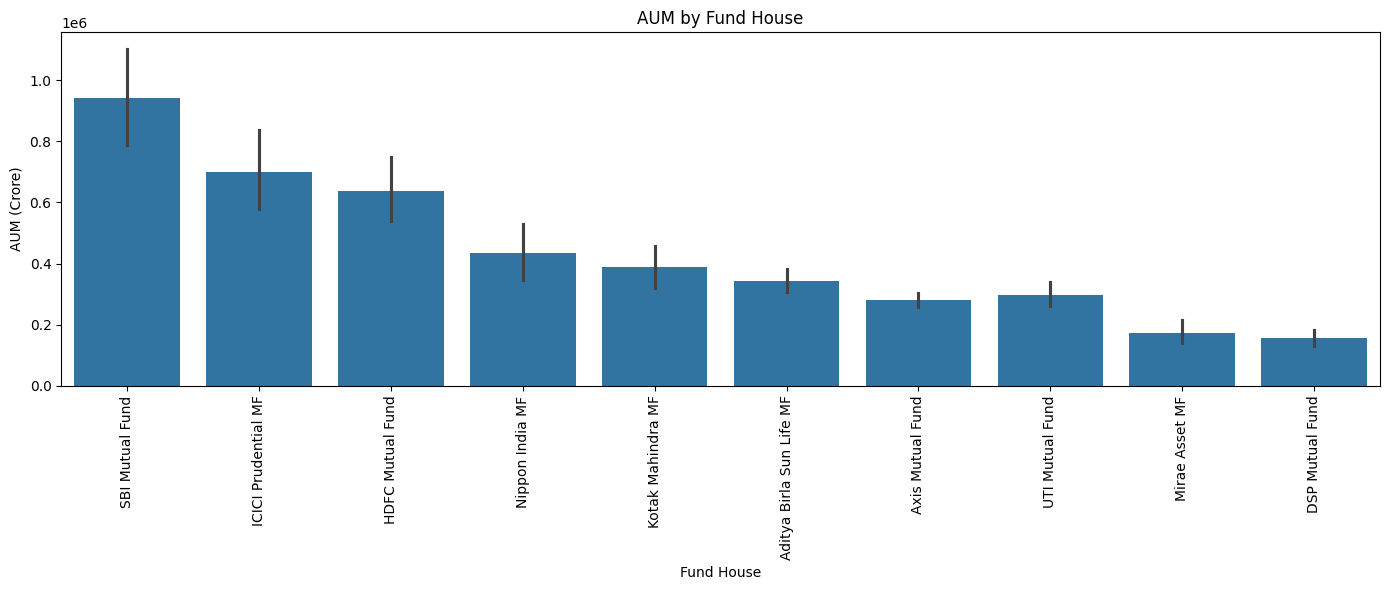

In [237]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_crore"
)

plt.title("AUM by Fund House")
plt.xticks(rotation=90)
plt.xlabel("Fund House")
plt.ylabel("AUM (Crore)")
plt.tight_layout()

plt.show()

In [238]:
# Load SIP data
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows.csv")

print(sip.head())
print("\nColumns:", sip.columns)
print("\nShape:", sip.shape)

     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  

Columns: Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

Shape: (48, 6)


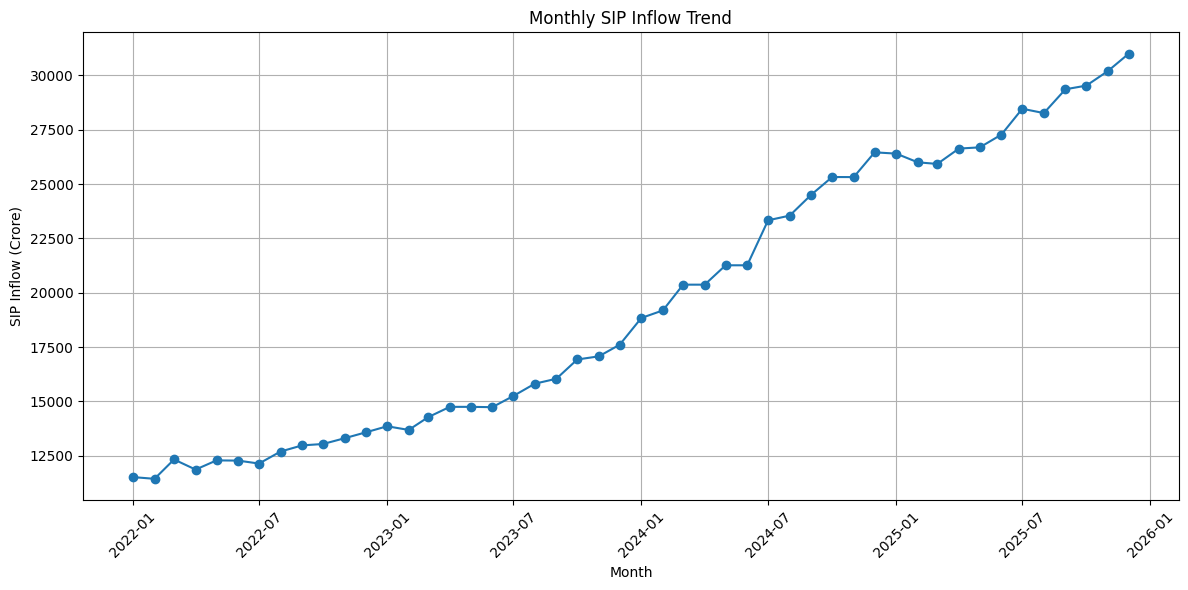

In [239]:
# Convert month to datetime
sip["month"] = pd.to_datetime(sip["month"])

# SIP Trend Chart
plt.figure(figsize=(12,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o"
)

plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

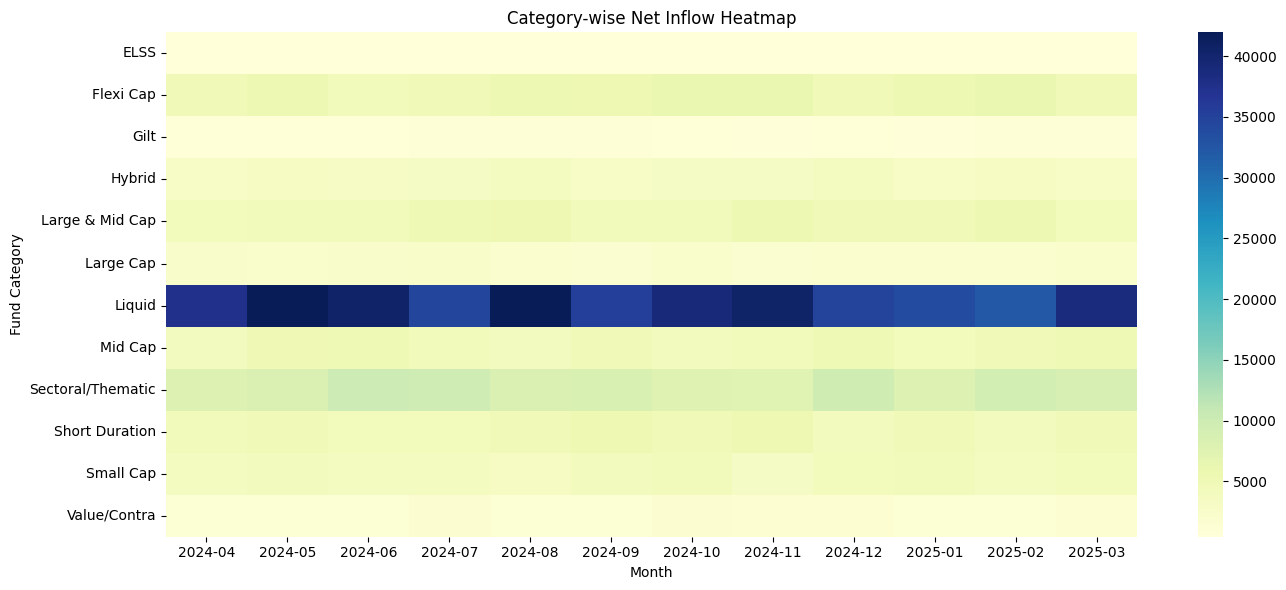

In [240]:
cat["month"] = pd.to_datetime(cat["month"])

heatmap_data = cat.pivot_table(
    values="net_inflow_crore",
    index="category",
    columns=cat["month"].dt.strftime("%Y-%m"),
    aggfunc="sum"
)

plt.figure(figsize=(14,6))
sns.heatmap(heatmap_data, cmap="YlGnBu")

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()
plt.show()

In [241]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load investor transactions data
inv = pd.read_csv("../data/processed/08_investor_transactions.csv")

# Check columns
print(inv.head())
print(inv.columns)
print(inv.shape)

  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female                54.4   
4        Delhi      Noida       T30     26-35    Male                14.5   

  payment_mode kyc_status  
0          UPI   Verified  
1       Cheque   Verified  
2      M

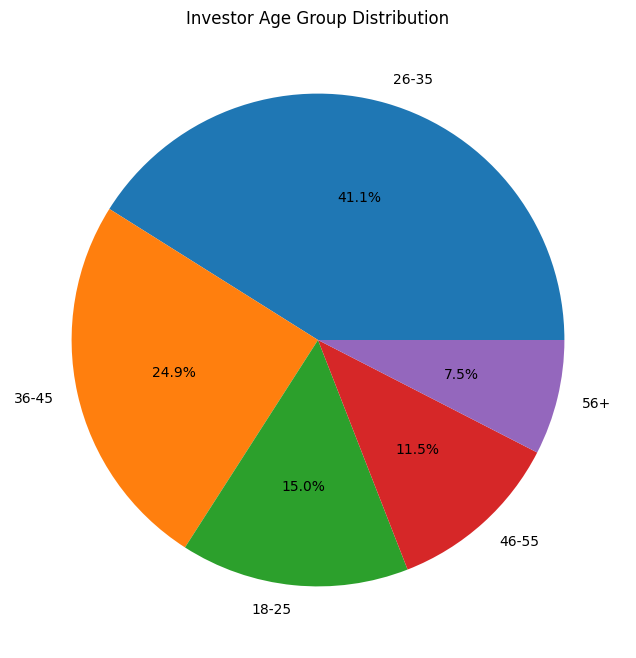

In [242]:
# Age Group Distribution

plt.figure(figsize=(8,8))

inv["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")
plt.show()

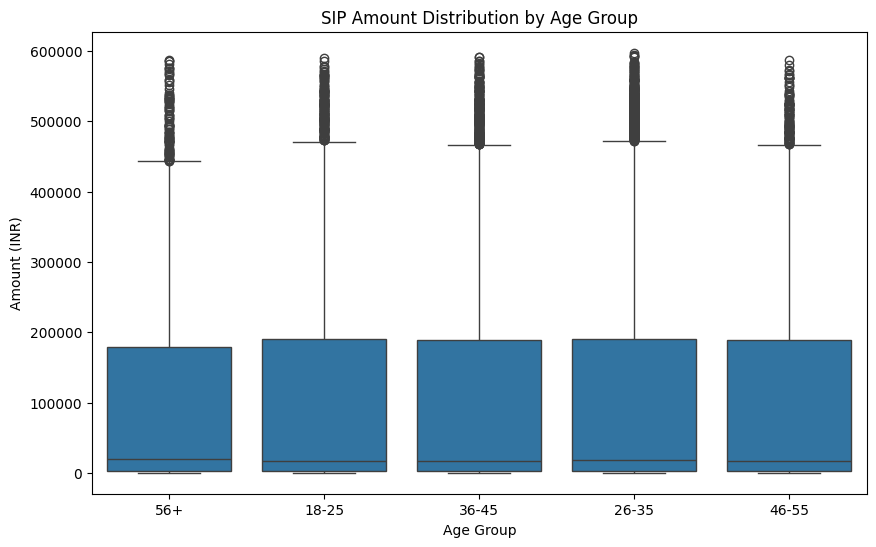

In [243]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=inv,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (INR)")

plt.show()

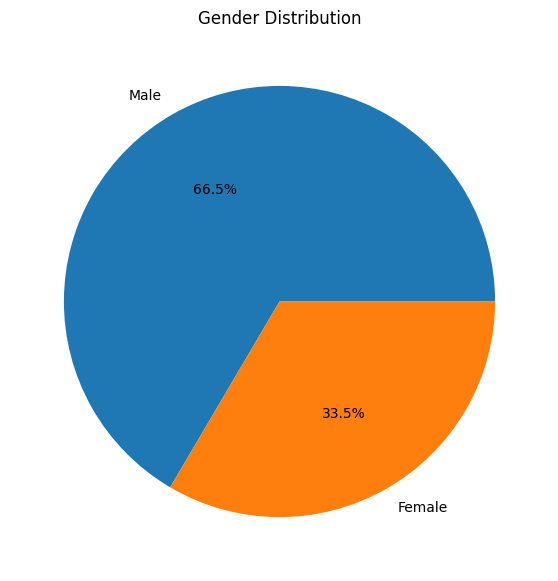

In [244]:
plt.figure(figsize=(7,7))

inv["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")
plt.ylabel("")

plt.show()

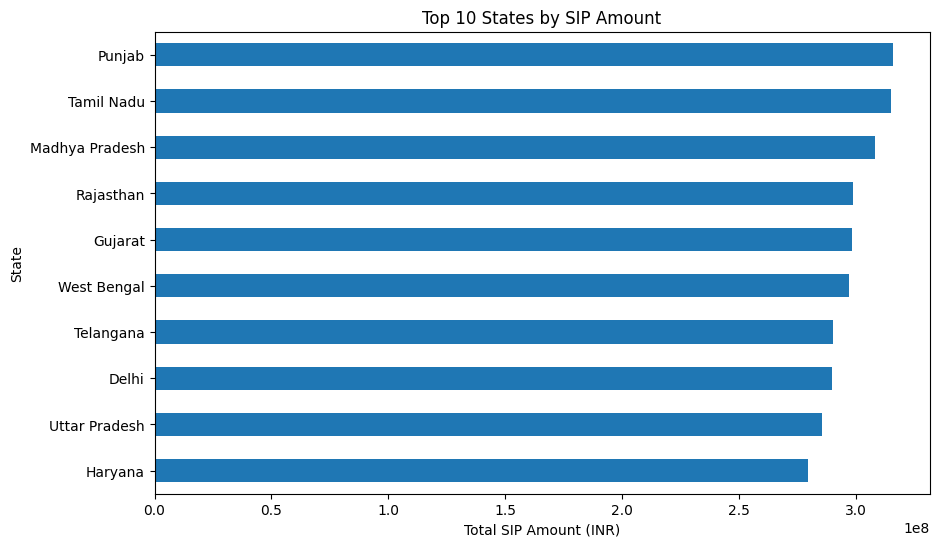

In [245]:
state_data = inv.groupby("state")["amount_inr"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

state_data.plot(kind="barh")

plt.title("Top 10 States by SIP Amount")
plt.xlabel("Total SIP Amount (INR)")
plt.ylabel("State")

plt.gca().invert_yaxis()
plt.show()

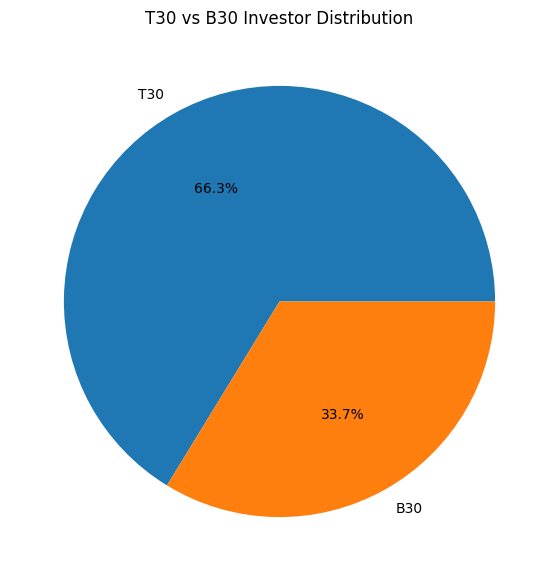

In [246]:
plt.figure(figsize=(7,7))

inv["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")
plt.ylabel("")

plt.show()

In [247]:
# Load folio count data
folio = pd.read_csv("../data/processed/06_industry_folio_count.csv")

# Check data
print(folio.head())
print("\nColumns:", folio.columns)
print("\nShape:", folio.shape)

     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  

Columns: Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

Shape: (21, 6)


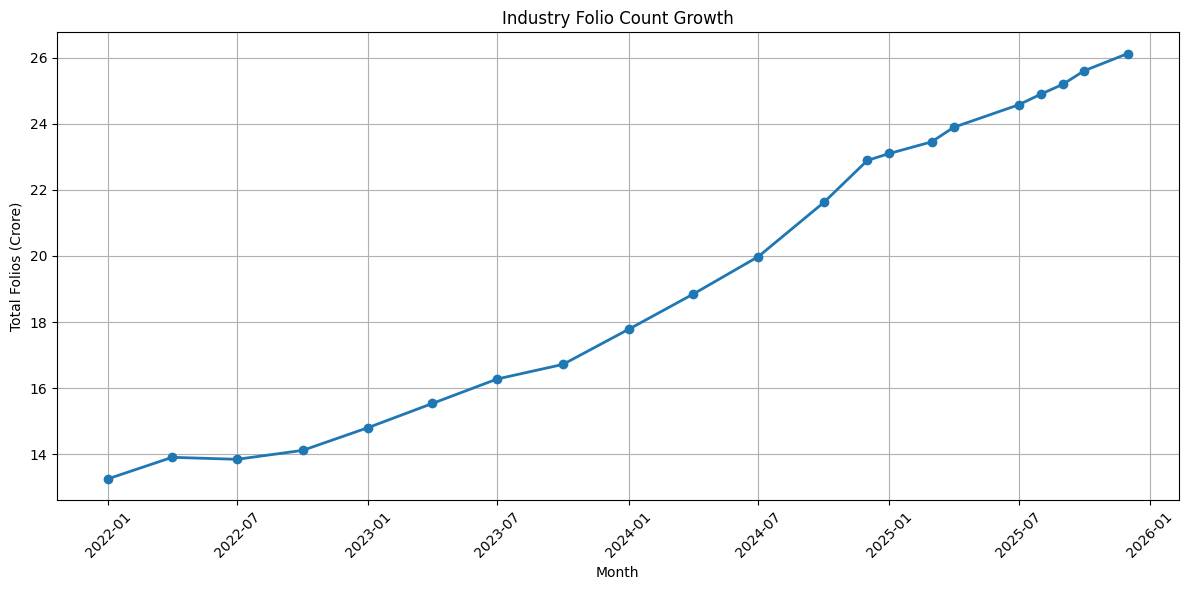

In [248]:
# Convert month to datetime
folio["month"] = pd.to_datetime(folio["month"])

# Plot Folio Growth
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2
)

plt.title("Industry Folio Count Growth")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [249]:
holdings = pd.read_csv("../data/processed/09_portfolio_holdings.csv")

print(holdings.head())
print("\nColumns:", holdings.columns)
print("\nShape:", holdings.shape)

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  

Columns: Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

Shape: (322, 8)


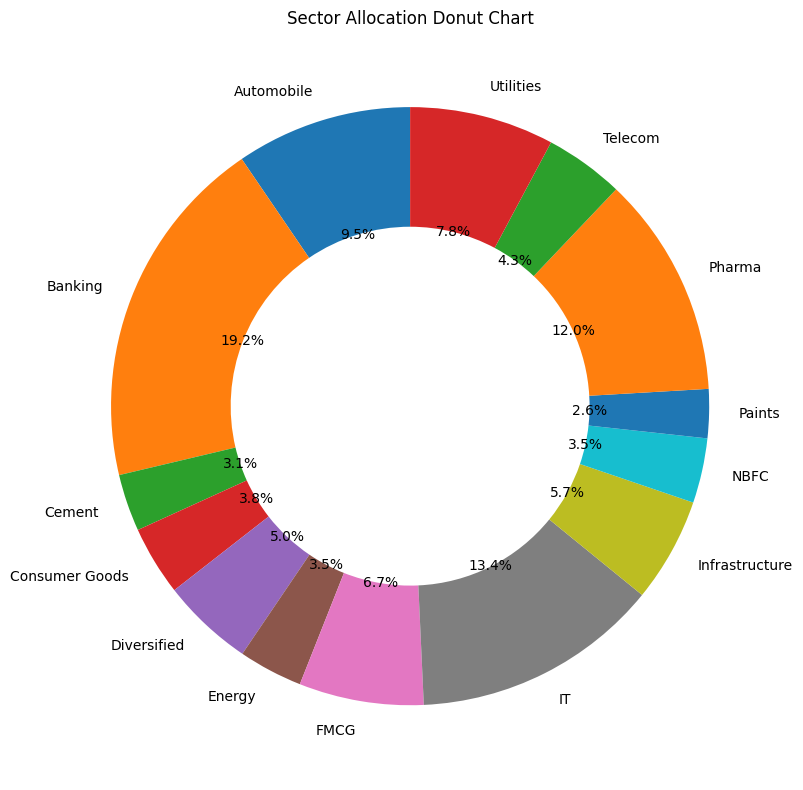

In [250]:
# Sector Allocation Donut Chart

sector_data = holdings.groupby("sector")["weight_pct"].sum()

plt.figure(figsize=(10,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}   # Donut effect
)

plt.title("Sector Allocation Donut Chart")

plt.tight_layout()
plt.show()

In [251]:
perf = pd.read_csv("../data/processed/07_scheme_performance.csv")

print(perf.head())
print("\nColumns:", perf.columns)
print("\nShape:", perf.shape)

   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   
2  Small Cap  Regular           24.56           23.39           20.67   
3  Small Cap   Direct           20.59           23.14           21.82   
4       Gilt  Regular            5.34            6.07            5.43   

   benchmark_3yr_pct  alpha  beta  sharpe_ratio  sortino_ratio  \
0              11.49

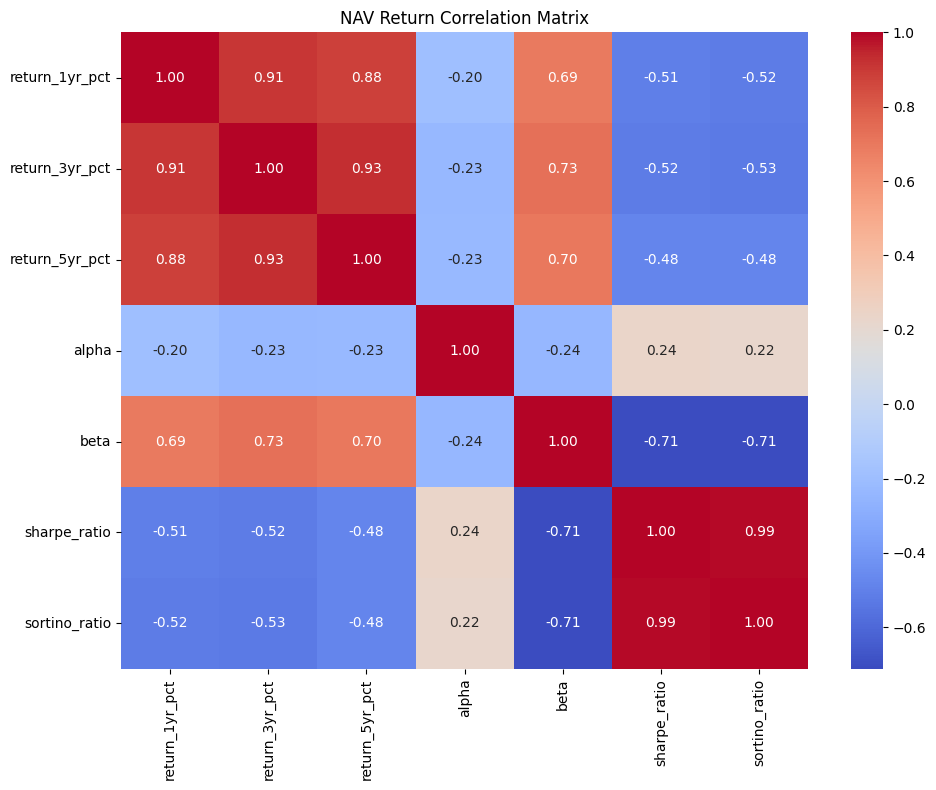

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation ke liye columns select karo
corr_data = perf[
    [
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct",
        "alpha",
        "beta",
        "sharpe_ratio",
        "sortino_ratio"
    ]
]

# Correlation matrix
corr_matrix = corr_data.corr()

# Heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("NAV Return Correlation Matrix")
plt.tight_layout()
plt.show()
-